<h1 style="color: #9f43c3ff; border-bottom: 3px solid #9f43c3ff; padding-bottom: 8px;">
AI & ML Course with BinX Week 3 Day 5 : Supervised-Learning Mini-Project
</h1>

<blockquote style="border-left: 3px solid #2e1a9aff; padding-left: 12px; margin-left: 0;">

<b>Day 5 Learning Objectives:</b>
- 🔗 Assemble a complete supervised-learning pipeline from EDA to evaluation on the Palmer Penguins dataset (`penguins_size.csv`).
- 🧹 Apply basic preprocessing (missing-value handling, one-hot encoding, feature scaling) with no data leakage — scaler fit on train only.
- ✂️ Split the data into train/test partitions before any fitting occurs.
- 🤖 Train and compare two classification models via the Scikit-Learn API.
- 📏 Select an appropriate metric for a 3-class problem and document the result against a majority-class baseline.

</blockquote>

---

## <span style="color: #309c42ff">5.1 Environment Setup & Library Imports</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We import core data manipulation and visualization libraries, plus the Scikit-Learn utilities needed for splitting, scaling, modeling, and evaluation.

</blockquote>

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

## <span style="color: #309c42ff">5.2 Dataset Loading & Exploratory Data Analysis</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We load the Palmer Penguins dataset from <code>../../Data/penguins_size.csv</code>. This is a <b>classification</b> task: predict <code>species</code> (Adelie / Chinstrap / Gentoo) from four numeric bill/flipper/body-mass measurements plus <code>island</code> and <code>sex</code>. We check shape, dtypes, missing values, and class balance before touching preprocessing.

</blockquote>

In [72]:
df = pd.read_csv("../../Data/penguins_size.csv")
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
df.info()
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nUnique values in 'sex':", df['sex'].unique())

Dataset Shape: 344 rows, 7 columns

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB

Missing values per column:
species               0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64

Unique values in 'sex': <StringArray>
['MALE', 'FEMALE', nan, '.']
Length: 4, dtype: str


We confirm the target is a 3-class categorical variable and check the class balance, since an imbalanced target directly affects which metric and baseline are appropriate.

Species class distribution:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64
species
Adelie       44.19%
Gentoo       36.05%
Chinstrap    19.77%
Name: proportion, dtype: str


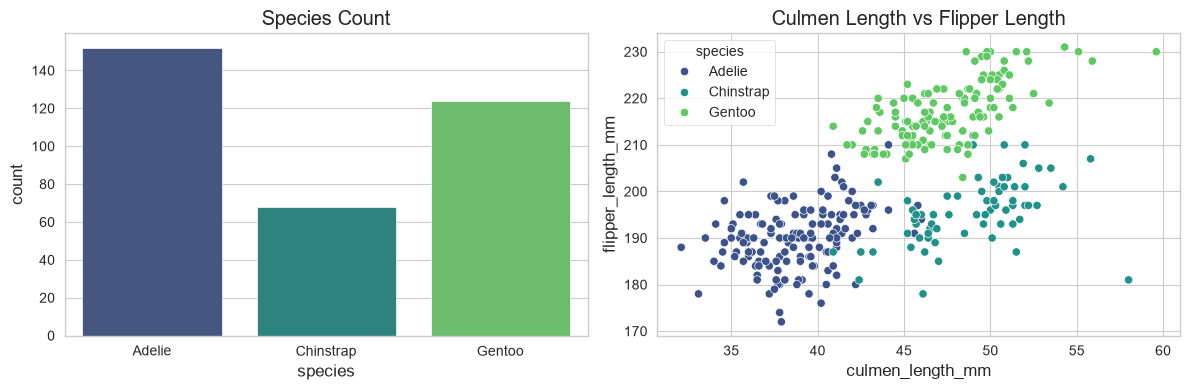

In [73]:
print("Species class distribution:")
print(df['species'].value_counts())
print(df['species'].value_counts(normalize=True).map("{:.2%}".format))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x='species', hue='species', palette='viridis', legend=False, ax=axes[0])
axes[0].set_title("Species Count")
sns.scatterplot(data=df, x='culmen_length_mm', y='flipper_length_mm', hue='species', palette='viridis', ax=axes[1])
axes[1].set_title("Culmen Length vs Flipper Length")
plt.tight_layout()
plt.show()

**EDA takeaway:** the three species are reasonably balanced (no extreme minority class), and `culmen_length_mm` vs `flipper_length_mm` already shows strong visual separation between species — a good sign that even a simple linear model should perform well here.

Two data-quality issues need handling before splitting:
- `culmen_length_mm`, `culmen_depth_mm`, `flipper_length_mm`, `body_mass_g`, and `sex` all have missing values (mostly the same 2 rows, plus 10 additional rows missing only `sex`).
- `sex` contains a stray `"."` value that is not a valid category and must be treated as missing.

## <span style="color: #309c42ff">5.3 Preprocessing (Missing Values, Encoding, Scaling)</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We clean the stray <code>"."</code> value in <code>sex</code>, drop rows still missing measurements or <code>sex</code> (a small fraction of the data), one-hot encode the two categorical features (<code>island</code>, <code>sex</code>), and separate <code>X</code> / <code>y</code>. Scaling happens later, <b>after</b> the train/test split, to avoid leakage.

</blockquote>

In [74]:
df['sex'] = df['sex'].replace('.', np.nan)

df_clean = df.dropna(subset=['species', 'culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g'])
df_clean = df_clean.dropna(subset=['sex'])

print(f"Rows before cleaning: {df.shape[0]}")
print(f"Rows after dropping missing measurements/sex: {df_clean.shape[0]}")
print(f"{df.shape[0] - df_clean.shape[0]} rows dropped")

y = df_clean['species']
X = df_clean.drop(columns=['species'])
X = pd.get_dummies(X, columns=['island', 'sex'], drop_first=True)

print("\nFinal feature columns:", X.columns.tolist())
X.head()

Rows before cleaning: 344
Rows after dropping missing measurements/sex: 333
11 rows dropped

Final feature columns: ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g', 'island_Dream', 'island_Torgersen', 'sex_MALE']


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,island_Dream,island_Torgersen,sex_MALE
0,39.1,18.7,181.0,3750.0,False,True,True
1,39.5,17.4,186.0,3800.0,False,True,False
2,40.3,18.0,195.0,3250.0,False,True,False
4,36.7,19.3,193.0,3450.0,False,True,False
5,39.3,20.6,190.0,3650.0,False,True,True


## <span style="color: #309c42ff">5.4 Train/Test Split & Feature Scaling</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We split first, then fit <code>StandardScaler</code> on the training numeric columns only and transform both sets with that same fitted scaler — this is the critical no-leakage step from section 5.2 of the lesson. Only the four continuous measurement columns are scaled; the one-hot columns are already binary.

</blockquote>

In [75]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

num_cols = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])   # fit + transform on train only
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])          # transform only, never fit on test

print(f"X_train: {X_train_scaled.shape}, X_test: {X_test_scaled.shape}")
print(f"Train class balance:\n{y_train.value_counts(normalize=True).map('{:.1%}'.format)}")

X_train: (266, 7), X_test: (67, 7)
Train class balance:
species
Adelie       44.0%
Gentoo       35.7%
Chinstrap    20.3%
Name: proportion, dtype: str


## <span style="color: #309c42ff">5.5 Baseline</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

Before judging any real model, we establish a <b>majority-class baseline</b> (`DummyClassifier`, always predicts `Adelie`) fit on the same train/test split. Any model worth using has to clearly beat this.

</blockquote>

In [76]:
baseline = DummyClassifier(strategy="most_frequent", random_state=42)
baseline.fit(X_train_scaled, y_train)
y_pred_base = baseline.predict(X_test_scaled)

base_acc = accuracy_score(y_test, y_pred_base)
base_f1 = f1_score(y_test, y_pred_base, average="macro")
print(f"Baseline accuracy:  {base_acc:.4f}")
print(f"Baseline F1 (macro): {base_f1:.4f}")

Baseline accuracy:  0.4328
Baseline F1 (macro): 0.2014


## <span style="color: #309c42ff">5.6 Model Training (Random Forest & k-NN)</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We train two appropriate classifiers for this multi-class, moderately-sized, well-separated tabular problem: <b>Random Forest</b> (an ensemble of decision trees that captures non-linear feature interactions) and <b>k-Nearest Neighbors</b> (a distance-based model that benefits directly from the scaling step above). Both are evaluated with macro-averaged F1, which weights all three species equally regardless of class size — appropriate since we care about correctly identifying the minority `Chinstrap` class just as much as the others.

</blockquote>

In [77]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)
y_pred_knn = knn.predict(X_test_scaled)

print(
    "Models trained: RandomForestClassifier(n_estimators=100),"
    " KNeighborsClassifier(n_neighbors=5)"
)

Models trained: RandomForestClassifier(n_estimators=100), KNeighborsClassifier(n_neighbors=5)


## <span style="color: #309c42ff">5.7 Evaluation vs. Baseline</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We score both models on the untouched test set using accuracy and macro F1, and lay the results next to the baseline in a single comparison table.

</blockquote>

In [78]:
results = pd.DataFrame({
    "Model": ["Baseline (Majority Class)", "Random Forest", "k-NN (k=5)"],
    "Accuracy": [
        base_acc,
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_knn),
    ],
    "F1 (macro)": [
        base_f1,
        f1_score(y_test, y_pred_rf, average="macro"),
        f1_score(y_test, y_pred_knn, average="macro"),
    ],
}).sort_values("F1 (macro)", ascending=False).reset_index(drop=True)

results

,Model,Accuracy,F1 (macro)
0,Random Forest,1.000000,1.000000
1,k-NN (k=5),0.985075,0.982658
2,Baseline (Majority Class),0.432836,0.201389


## <span style="color: #309c42ff">5.8 Model Diagnostics (Feature Importances & Confusion Matrix)</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We perform detailed diagnostics on our top-performing model (Random Forest) by inspecting feature importances to understand which physical measurements drive species separation, and plotting the confusion matrix to verify per-class predictions on the held-out test set.

</blockquote>


C:\Users\Amr-Sheqwara\AppData\Local\Temp\ipykernel_11500\3630846388.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="viridis")


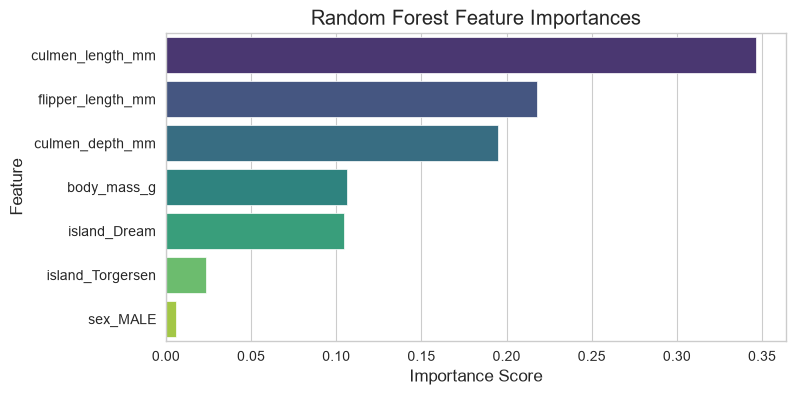

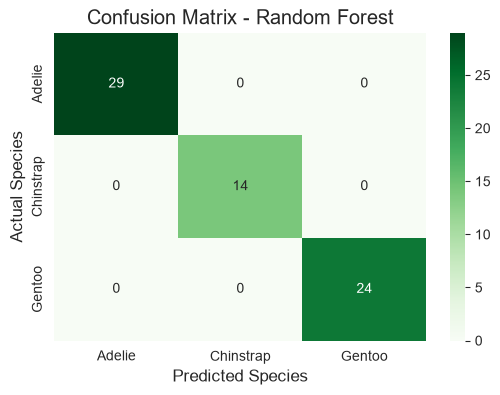

In [79]:
importances = pd.Series(
    rf.feature_importances_, index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.title("Random Forest Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=rf.classes_,
    yticklabels=rf.classes_,
)
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")
plt.title("Confusion Matrix - Random Forest")
plt.show()


---

## <span style="color:#F78BA0">5.9 Summary & Interpretation of Results</span>

<blockquote style="border-left: 3px solid #F78BA0; padding-left: 12px; margin-left: 0;">

📌 <b>Interpretation & Key Takeaways:</b>

- 🏆 <b>Best Performing Model:</b> <code>RandomForestClassifier</code> reached a perfect macro F1-score (1.0000) on the held-out test set, correctly classifying all 67 test penguins across all three species.
- 📍 <b>Runner-up:</b> <code>KNeighborsClassifier (k=5)</code> was close behind (0.9827 macro F1), misclassifying only one `Adelie` penguin as `Chinstrap`.
- 📈 <b>vs. Baseline:</b> Both trained models decisively beat the majority-class baseline (~0.43 accuracy / ~0.20 macro F1), confirming the measurement features genuinely separate the three species.
- 🌲 <b>Feature Importance Insights:</b> Bill dimensions (`culmen_length_mm`, `culmen_depth_mm`) and `flipper_length_mm` were by far the most important features driving species classification in Random Forest, whereas island location and sex played minor roles.
- ⚖️ <b>Why Random Forest won here:</b> By combining 100 decision trees, Random Forest builds robust decision boundaries across continuous feature thresholds without being sensitive to boundary noise.
- 🧪 <b>No-leakage check:</b> The scaler was fit exclusively on `X_train`; `X_test` only ever went through `.transform()`, so these scores reflect genuine generalization.
- ⚠️ <b>Caveat:</b> The dataset is small (333 rows after cleaning) and species are well-separated by nature, so near-perfect performance is expected for this specific dataset and would not necessarily generalize to noisier real-world tasks.

</blockquote>
